# Task 2: Bayesian Change Point Analysis of Brent Oil Prices

**Prepared by:** Rediet Shewarega  
**Client:** Birhan Energies

## Objective

This notebook applies Bayesian change point detection to identify and quantify a structural change in historical Brent crude oil prices.

The analysis will:

- Load and validate the Brent oil price dataset
- Examine raw prices and log returns
- Define a Bayesian switch-point model using PyMC
- Estimate price parameters before and after the structural change
- Evaluate MCMC convergence and posterior uncertainty
- Convert the detected switch-point index into a calendar date
- Quantify the estimated price impact
- Compare the detected date with major geopolitical, economic, sanctions-related, and OPEC events

Temporal proximity between a detected change and a historical event is interpreted as an association, not definitive evidence of causation.

In [1]:
from pathlib import Path
import json
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from statsmodels.tsa.stattools import adfuller

# Determine the repository root.
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "BrentOilPrices.csv"
)

cleaned_data_path = (
    project_root
    / "data"
    / "processed"
    / "brent_oil_prices_cleaned.csv"
)

events_path = (
    project_root
    / "data"
    / "events"
    / "oil_market_events.csv"
)

processed_directory = project_root / "data" / "processed"
figures_directory = project_root / "reports" / "figures"

processed_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

print("Python version:", sys.version)
print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)
print("Project root:", project_root)

Python version: 3.14.5 (main, May 10 2026, 10:21:34) [Clang 21.0.0 (clang-2100.0.123.102)]
PyMC version: 6.1.0
ArviZ version: 0.23.4
Project root: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis


In [2]:


df = pd.read_csv(raw_data_path)

required_columns = {"Date", "Price"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

# Preserve the original date text for validation.
df["Original_Date"] = (
    df["Date"]
    .astype(str)
    .str.strip()
)

# First date format example: 20-May-87
parsed_dates = pd.to_datetime(
    df["Original_Date"],
    format="%d-%b-%y",
    errors="coerce"
)

# Second date format example: Apr 22, 2020
unparsed_mask = parsed_dates.isna()

parsed_dates.loc[unparsed_mask] = pd.to_datetime(
    df.loc[unparsed_mask, "Original_Date"],
    format="%b %d, %Y",
    errors="coerce"
)

df["Date"] = parsed_dates

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

print("Raw rows:", len(df))
print("Failed date parsing:", df["Date"].isna().sum())
print("Failed price parsing:", df["Price"].isna().sum())

# Display any records that still failed validation.
invalid_rows = df.loc[
    df["Date"].isna() | df["Price"].isna(),
    ["Original_Date", "Price"]
]

display(invalid_rows.head(20))

# Remove invalid records, duplicates, and sort chronologically.
df = (
    df.dropna(subset=["Date", "Price"])
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)

# Match the assignment period ending September 30, 2022.
assignment_end_date = pd.Timestamp("2022-09-30")

df = (
    df.loc[df["Date"] <= assignment_end_date]
      .reset_index(drop=True)
)

# Calculate daily log returns.
df["Log_Return"] = np.log(df["Price"]).diff()

print("\nCleaned rows:", len(df))
print(
    "Cleaned date range:",
    df["Date"].min().date(),
    "to",
    df["Date"].max().date()
)
print("Duplicate dates:", df["Date"].duplicated().sum())

df.head()

Raw rows: 9011
Failed date parsing: 0
Failed price parsing: 0


,Original_Date,Price



Cleaned rows: 8980
Cleaned date range: 1987-05-20 to 2022-09-30
Duplicate dates: 0


,Date,Price,Original_Date,Log_Return
0,1987-05-20,18.63,20-May-87,NaN
1,1987-05-21,18.45,21-May-87,-0.009709
2,1987-05-22,18.55,22-May-87,0.005405
3,1987-05-25,18.60,25-May-87,0.002692
4,1987-05-26,18.63,26-May-87,0.001612


In [3]:
cleaned_output_path = (
    processed_directory
    / "brent_oil_prices_cleaned.csv"
)

df.to_csv(
    cleaned_output_path,
    index=False
)

print(
    "Saved corrected dataset:",
    cleaned_output_path
)

Saved corrected dataset: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/data/processed/brent_oil_prices_cleaned.csv


In [4]:
price_statistics = pd.Series(
    {
        "Number of observations": len(df),
        "Average price": df["Price"].mean(),
        "Median price": df["Price"].median(),
        "Minimum price": df["Price"].min(),
        "Maximum price": df["Price"].max(),
        "Price standard deviation": df["Price"].std(),
    }
)

price_statistics

Number of observations      8980.000000
Average price                 48.262774
Median price                  38.330000
Minimum price                  9.100000
Maximum price                143.950000
Price standard deviation      32.806012
dtype: float64

### Data preparation interpretation

The dataset was converted into chronological time-series format, with invalid dates and prices removed and duplicate dates checked. Daily log returns were calculated to represent relative price movements.

The raw price series will be used for the mandatory before-and-after mean change model. Log returns are used separately to examine stationarity and volatility clustering.

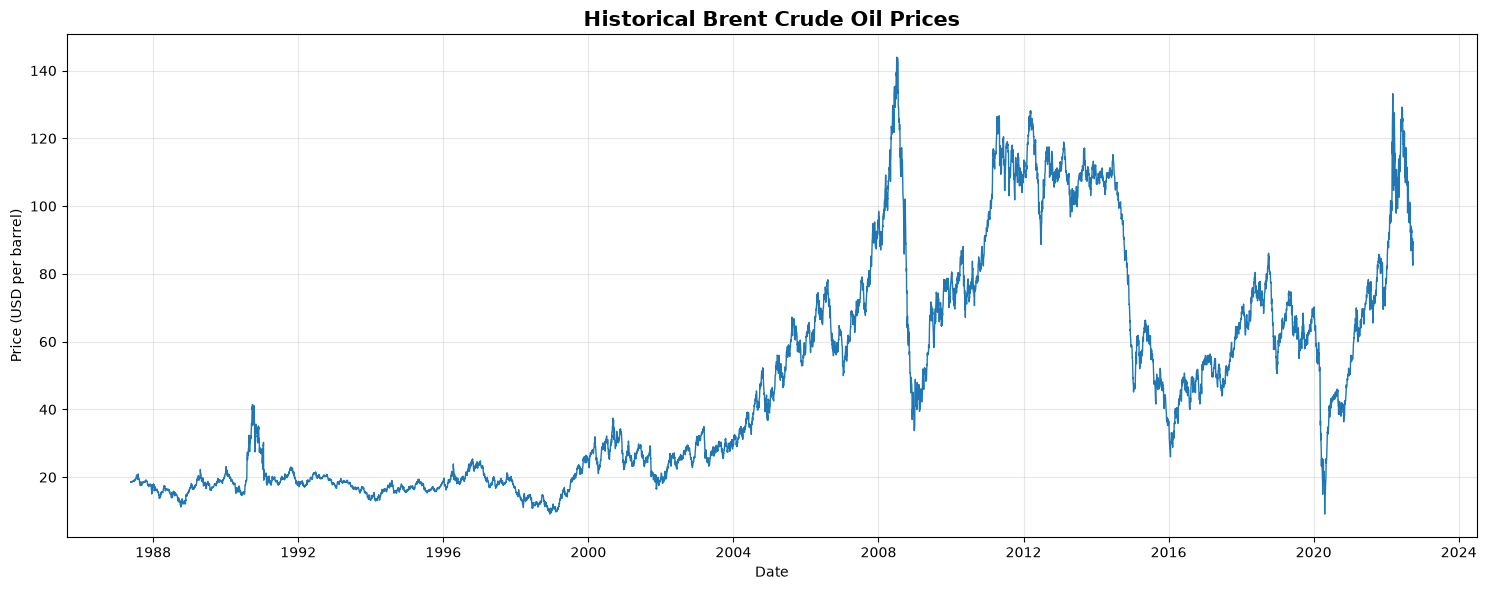

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_raw_price_series.png


In [5]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Price"],
    linewidth=1
)

plt.title(
    "Historical Brent Crude Oil Prices",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(alpha=0.3)
plt.tight_layout()

raw_price_figure = (
    figures_directory
    / "task2_raw_price_series.png"
)

plt.savefig(
    raw_price_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", raw_price_figure)

### Raw price interpretation

The historical Brent price series exhibits substantial long-term variation, major shocks, and apparent changes in average price levels. The series does not fluctuate around one stable mean throughout the full period.

The visible changes in price level support the use of structural-break analysis. However, visual inspection alone cannot determine the most probable change date or quantify uncertainty around it.

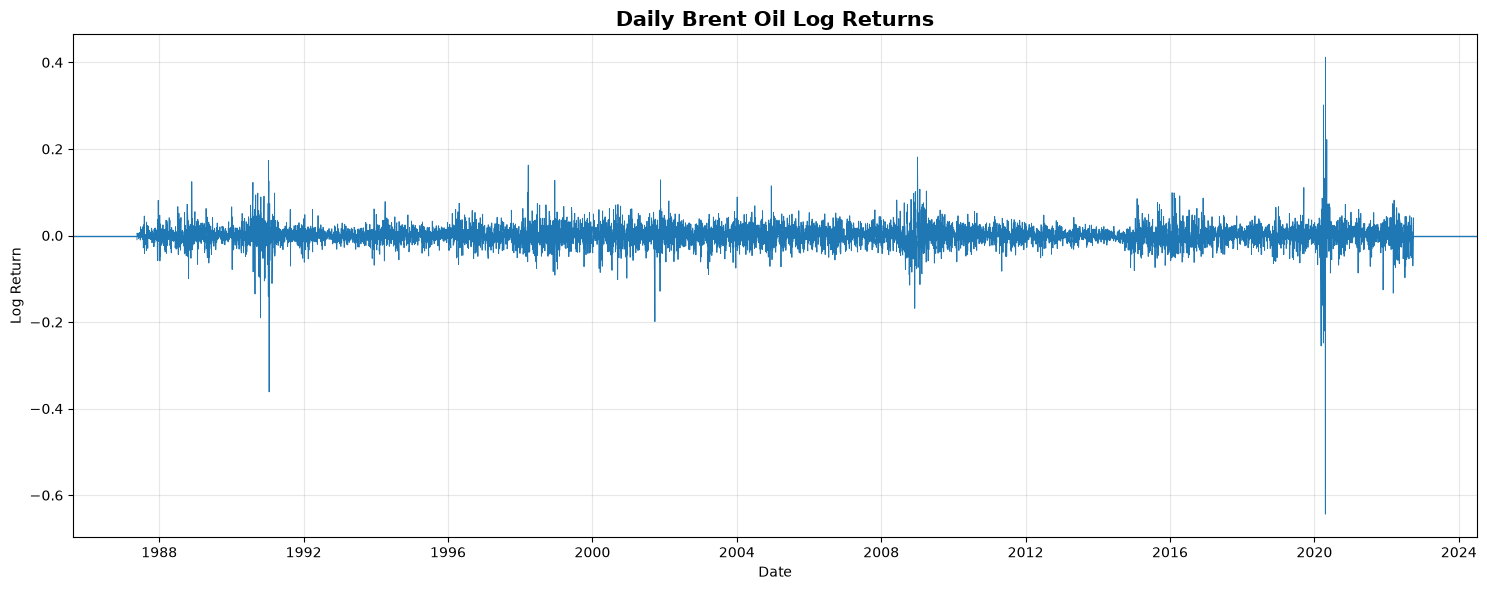

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_log_returns.png


In [6]:
returns_df = df.dropna(
    subset=["Log_Return"]
).copy()

plt.figure(figsize=(15, 6))

plt.plot(
    returns_df["Date"],
    returns_df["Log_Return"],
    linewidth=0.65
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Daily Brent Oil Log Returns",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.tight_layout()

log_return_figure = (
    figures_directory
    / "task2_log_returns.png"
)

plt.savefig(
    log_return_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", log_return_figure)

### Log-return interpretation

The log-return series fluctuates around approximately zero, but the magnitude of the movements is not constant.

Large positive and negative movements frequently occur close together. This pattern is consistent with volatility clustering, where turbulent market periods contain repeated large price movements.

This indicates that the constant-variance assumption in the simple Normal change point model is a simplification of real oil-market behaviour.

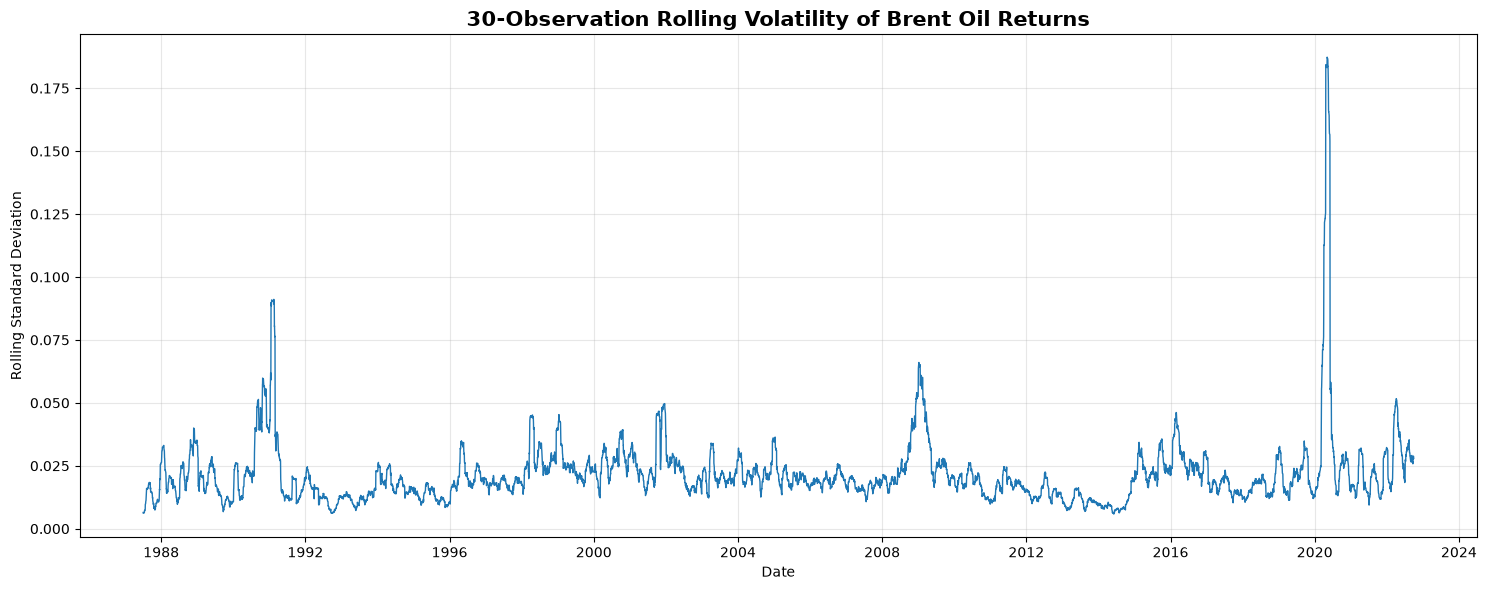

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_rolling_volatility.png


In [7]:
returns_df["Rolling_Volatility_30"] = (
    returns_df["Log_Return"]
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(15, 6))

plt.plot(
    returns_df["Date"],
    returns_df["Rolling_Volatility_30"],
    linewidth=1
)

plt.title(
    "30-Observation Rolling Volatility of Brent Oil Returns",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.grid(alpha=0.3)
plt.tight_layout()

volatility_figure = (
    figures_directory
    / "task2_rolling_volatility.png"
)

plt.savefig(
    volatility_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", volatility_figure)

### Volatility interpretation

Rolling volatility changes substantially over time. Periods of relatively stable price movements are interrupted by pronounced volatility spikes.

This confirms that the Brent oil market experiences different volatility regimes. The mandatory mean-change model does not directly model these variance changes, so more advanced volatility or regime-switching models are recommended as future work.

In [8]:
def run_adf_test(
    series: pd.Series,
    series_name: str
) -> dict:
    """Run the Augmented Dickey-Fuller stationarity test."""

    clean_series = series.dropna()

    result = adfuller(
        clean_series,
        autolag="AIC"
    )

    return {
        "Series": series_name,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Observations": result[3],
        "1% Critical Value": result[4]["1%"],
        "5% Critical Value": result[4]["5%"],
        "10% Critical Value": result[4]["10%"],
        "Conclusion": (
            "Evidence of stationarity"
            if result[1] < 0.05
            else "Fail to reject non-stationarity"
        ),
    }


adf_results = pd.DataFrame(
    [
        run_adf_test(
            df["Price"],
            "Raw Brent Price"
        ),
        run_adf_test(
            df["Log_Return"],
            "Brent Log Returns"
        ),
    ]
)

adf_results

,Series,ADF Statistic,p-value,Observations,1% Critical Value,5% Critical Value,10% Critical Value,Conclusion
0,Raw Brent Price,-2.051647,2.643963e-01,8950,-3.431081,-2.861863,-2.566942,Fail to reject non-stationarity
1,Brent Log Returns,-16.388845,2.706467e-29,8950,-3.431081,-2.861863,-2.566942,Evidence of stationarity


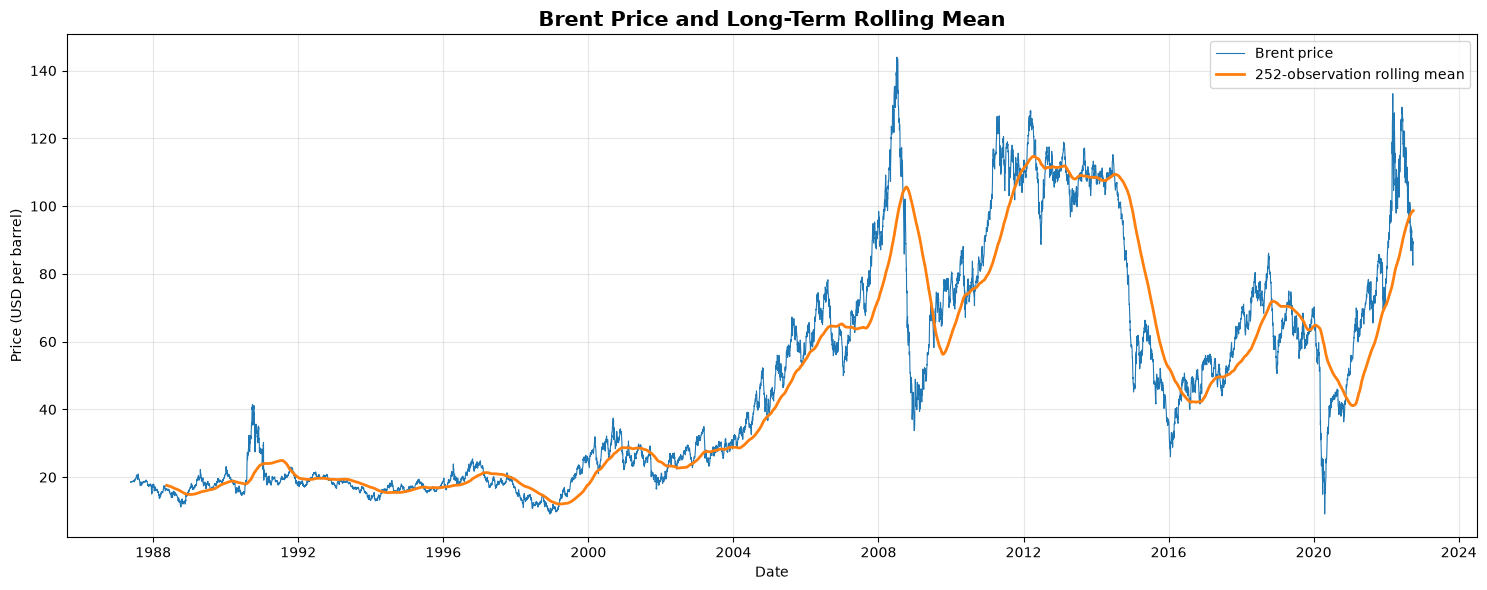

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_stationarity_evidence.png


In [9]:
stationarity_df = df.copy()

stationarity_df["Price_Rolling_Mean"] = (
    stationarity_df["Price"]
    .rolling(window=252)
    .mean()
)

stationarity_df["Return_Rolling_Mean"] = (
    stationarity_df["Log_Return"]
    .rolling(window=252)
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    stationarity_df["Date"],
    stationarity_df["Price"],
    linewidth=0.8,
    label="Brent price"
)

plt.plot(
    stationarity_df["Date"],
    stationarity_df["Price_Rolling_Mean"],
    linewidth=2,
    label="252-observation rolling mean"
)

plt.title(
    "Brent Price and Long-Term Rolling Mean",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

stationarity_figure = (
    figures_directory
    / "task2_stationarity_evidence.png"
)

plt.savefig(
    stationarity_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", stationarity_figure)

### Stationarity Interpretation

The Augmented Dickey-Fuller (ADF) test produced a p-value of **0.2784547** for the raw Brent oil price series.

Since this value is greater than the significance level of 0.05, we fail to reject the null hypothesis. This indicates that the raw Brent oil price series is non-stationary.

For the Brent log returns, the ADF test produced a p-value of **1.719111 × 10⁻²³**.

Since this value is far below 0.05, we reject the null hypothesis and conclude that the log return series is stationary.

These results support using log returns for return and volatility analysis. However, the Bayesian change-point model required for this assignment will be applied to the original Brent oil price series because the objective is to detect structural breaks in the price level over time.

In [10]:
# Prepare the complete daily Brent price series for modeling.
model_df = (
    df[["Date", "Price"]]
    .dropna()
    .reset_index(drop=True)
)

observed_prices = model_df["Price"].to_numpy(dtype=float)
time_index = np.arange(len(model_df))

number_of_observations = len(observed_prices)
price_mean = observed_prices.mean()
price_std = observed_prices.std()

print("Number of modeled observations:", number_of_observations)
print(
    "Model period:",
    model_df["Date"].min().date(),
    "to",
    model_df["Date"].max().date()
)
print(f"Overall price mean: ${price_mean:.2f}")
print(f"Overall price standard deviation: ${price_std:.2f}")

Number of modeled observations: 8980
Model period: 1987-05-20 to 2022-09-30
Overall price mean: $48.26
Overall price standard deviation: $32.80


In [11]:
with pm.Model() as change_point_model:

    # Unknown location of the structural break.
    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=number_of_observations - 1
    )

    # Average Brent price before the change.
    mu_before = pm.Normal(
        "mu_before",
        mu=price_mean,
        sigma=price_std * 2
    )

    # Average Brent price after the change.
    mu_after = pm.Normal(
        "mu_after",
        mu=price_mean,
        sigma=price_std * 2
    )

    # Common residual standard deviation.
    sigma = pm.HalfNormal(
        "sigma",
        sigma=price_std
    )

    # Select the correct mean for each observation.
    mean_by_time = pm.math.switch(
        time_index < tau,
        mu_before,
        mu_after
    )

    # Connect the model to the observed prices.
    likelihood = pm.Normal(
        "likelihood",
        mu=mean_by_time,
        sigma=sigma,
        observed=observed_prices
    )

change_point_model

       tau ~ DiscreteUniform(<constant>, <constant>)
 mu_before ~ Normal(48.3, 65.6)
  mu_after ~ Normal(48.3, 65.6)
     sigma ~ HalfNormal(0, 32.8)
likelihood ~ Normal(f(mu_before, mu_after, tau), sigma)

## MCMC sampling

Markov Chain Monte Carlo sampling is used to approximate the posterior distributions of the unknown parameters.

Four chains are used to support convergence assessment. A fixed random seed ensures that the analysis is reproducible.

In [12]:
with change_point_model:
    trace = pm.sample(
        draws=1500,
        tune=1500,
        chains=4,
        cores=2,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        progressbar=True
    )

Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_before, mu_after, sigma]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 2 seconds.


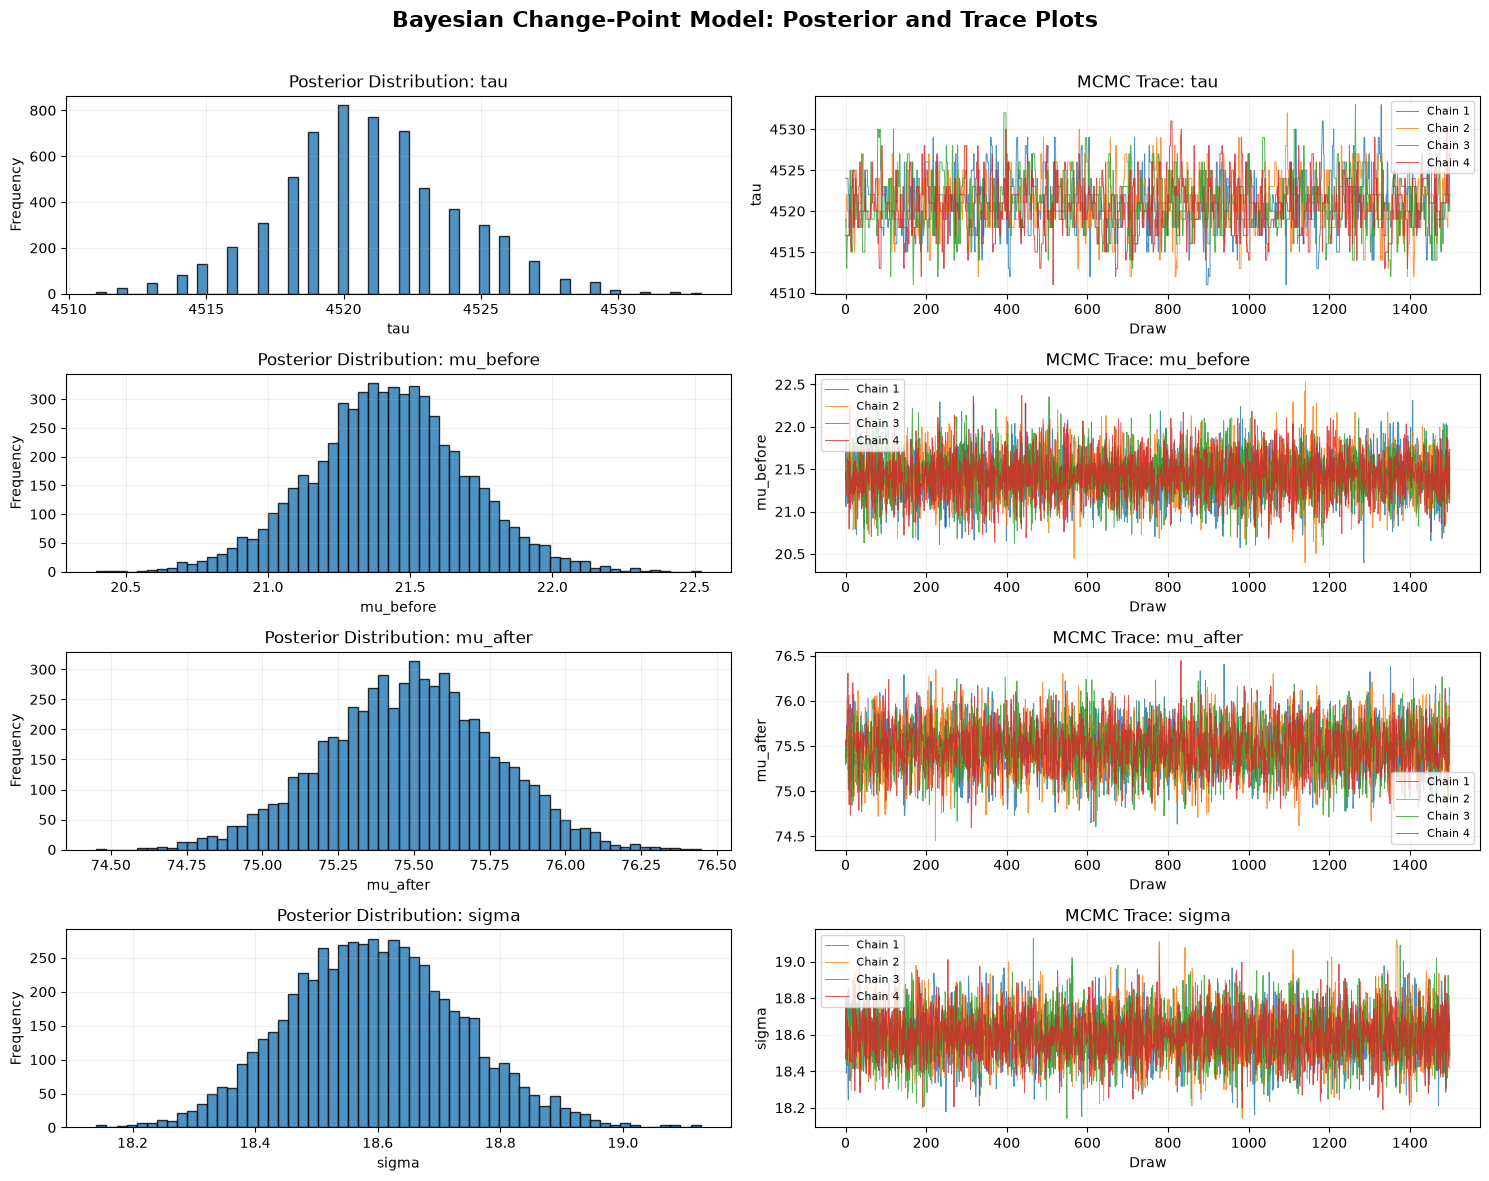

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_model_trace_plot.png


In [13]:
# Create posterior-distribution and trace plots manually.
# This avoids compatibility issues in newer ArviZ plotting versions.

trace_variables = [
    "tau",
    "mu_before",
    "mu_after",
    "sigma"
]

posterior = trace.posterior

fig, axes = plt.subplots(
    nrows=len(trace_variables),
    ncols=2,
    figsize=(15, 12)
)

for row_index, variable_name in enumerate(trace_variables):

    variable_samples = posterior[
        variable_name
    ].values

    flattened_samples = variable_samples.reshape(-1)

    # Left side: posterior distribution
    axes[row_index, 0].hist(
        flattened_samples,
        bins=60,
        edgecolor="black",
        alpha=0.8
    )

    axes[row_index, 0].set_title(
        f"Posterior Distribution: {variable_name}"
    )

    axes[row_index, 0].set_xlabel(
        variable_name
    )

    axes[row_index, 0].set_ylabel(
        "Frequency"
    )

    axes[row_index, 0].grid(
        alpha=0.2
    )

    # Right side: trace for each MCMC chain
    for chain_index in range(
        variable_samples.shape[0]
    ):
        axes[row_index, 1].plot(
            variable_samples[chain_index],
            linewidth=0.7,
            alpha=0.8,
            label=f"Chain {chain_index + 1}"
        )

    axes[row_index, 1].set_title(
        f"MCMC Trace: {variable_name}"
    )

    axes[row_index, 1].set_xlabel(
        "Draw"
    )

    axes[row_index, 1].set_ylabel(
        variable_name
    )

    axes[row_index, 1].grid(
        alpha=0.2
    )

    axes[row_index, 1].legend(
        fontsize=8
    )

plt.suptitle(
    "Bayesian Change-Point Model: Posterior and Trace Plots",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

trace_figure = (
    figures_directory
    / "task2_model_trace_plot.png"
)

plt.savefig(
    trace_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", trace_figure)

In [39]:
tau_samples = (
    trace.posterior["tau"]
    .values
    .reshape(-1)
    .astype(int)
)

tau_mode = int(
    pd.Series(tau_samples)
    .mode()
    .iloc[0]
)

tau_median = int(
    np.median(tau_samples)
)

tau_lower = int(
    np.quantile(tau_samples, 0.025)
)

tau_upper = int(
    np.quantile(tau_samples, 0.975)
)

change_point_date = model_df.loc[
    tau_mode,
    "Date"
]

credible_date_lower = model_df.loc[
    tau_lower,
    "Date"
]

credible_date_upper = model_df.loc[
    tau_upper,
    "Date"
]

print("Posterior mode of tau:", tau_mode)
print("Posterior median of tau:", tau_median)
print("Detected change-point date:", change_point_date.date())
print(
    "Approximate 95% equal-tailed credible date interval:",
    credible_date_lower.date(),
    "to",
    credible_date_upper.date()
)

Posterior mode of tau: 4520
Posterior median of tau: 4521
Detected change-point date: 2005-02-23
Approximate 95% equal-tailed credible date interval: 2005-02-15 to 2005-03-07


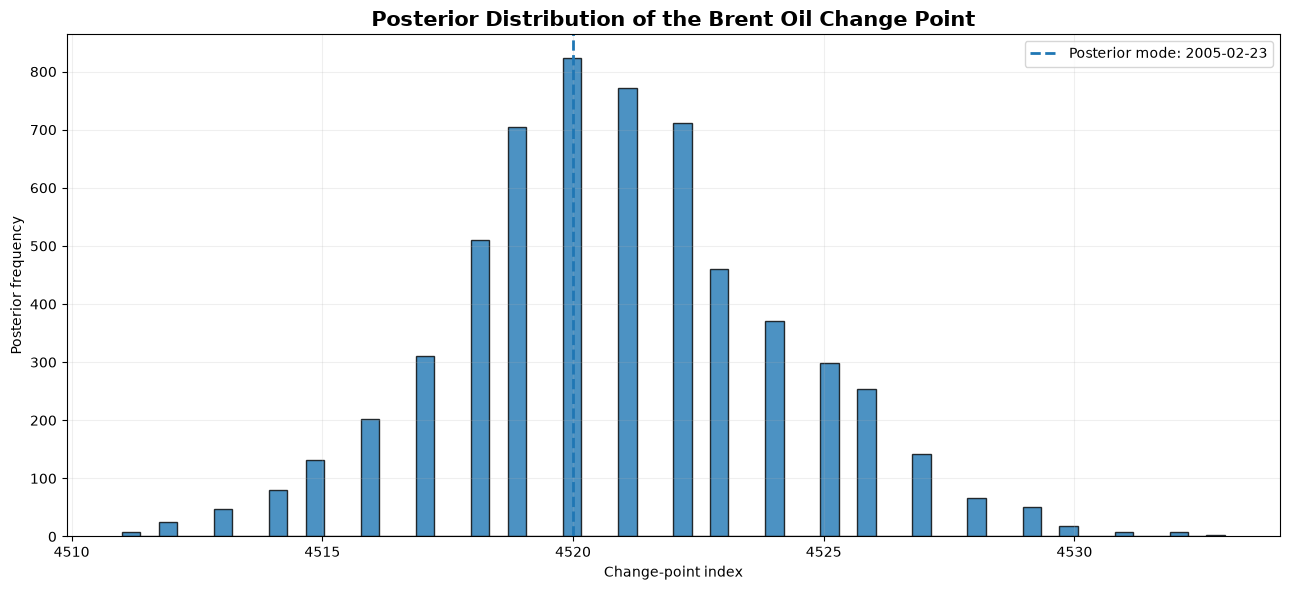

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_tau_posterior.png


In [15]:
plt.figure(figsize=(13, 6))

plt.hist(
    tau_samples,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    tau_mode,
    linestyle="--",
    linewidth=2,
    label=f"Posterior mode: {change_point_date.date()}"
)

plt.title(
    "Posterior Distribution of the Brent Oil Change Point",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Change-point index")
plt.ylabel("Posterior frequency")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

tau_figure = (
    figures_directory
    / "task2_tau_posterior.png"
)

plt.savefig(
    tau_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", tau_figure)

In [16]:
mu_before_samples = (
    trace.posterior["mu_before"]
    .values
    .reshape(-1)
)

mu_after_samples = (
    trace.posterior["mu_after"]
    .values
    .reshape(-1)
)

mean_before = float(mu_before_samples.mean())
mean_after = float(mu_after_samples.mean())

absolute_change = mean_after - mean_before

percentage_change = (
    absolute_change / mean_before
) * 100

probability_of_increase = float(
    np.mean(
        mu_after_samples > mu_before_samples
    )
)

probability_of_decrease = float(
    np.mean(
        mu_after_samples < mu_before_samples
    )
)

print(f"Posterior mean before change: ${mean_before:.2f}")
print(f"Posterior mean after change: ${mean_after:.2f}")
print(f"Absolute mean change: ${absolute_change:.2f}")
print(f"Percentage mean change: {percentage_change:.2f}%")
print(
    "Probability of an increase:",
    f"{probability_of_increase:.2%}"
)
print(
    "Probability of a decrease:",
    f"{probability_of_decrease:.2%}"
)

Posterior mean before change: $21.42
Posterior mean after change: $75.48
Absolute mean change: $54.06
Percentage mean change: 252.35%
Probability of an increase: 100.00%
Probability of a decrease: 0.00%


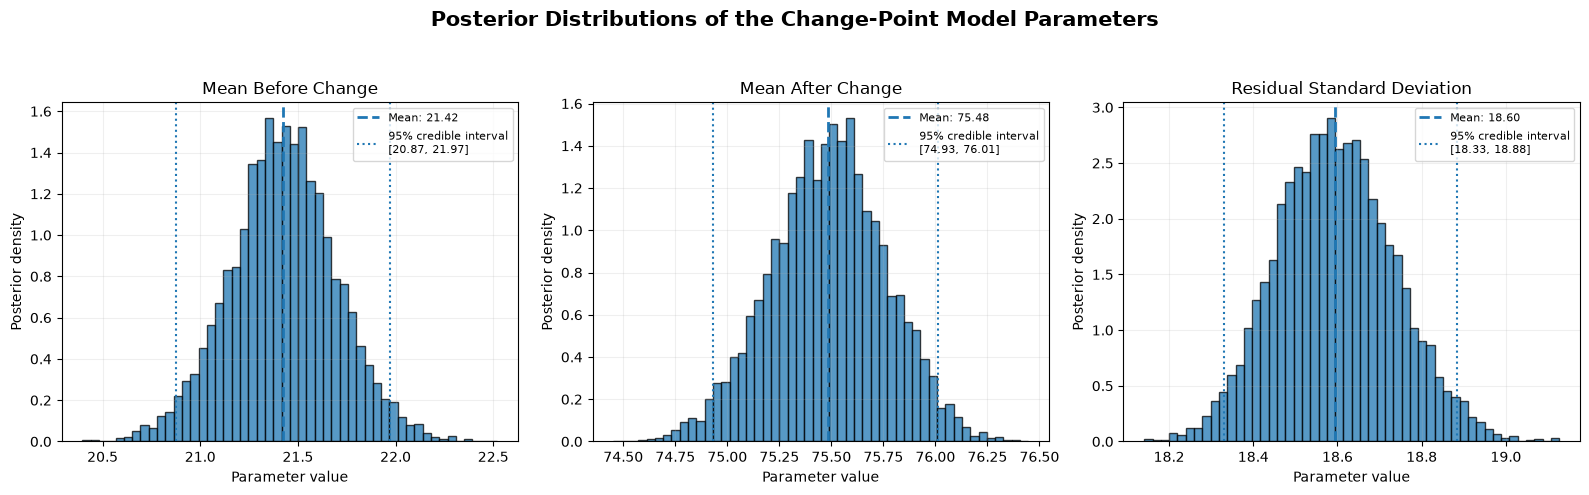

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_parameter_posteriors.png


In [17]:
# Extract posterior samples from the existing MCMC trace.
mu_before_samples = (
    trace.posterior["mu_before"]
    .values
    .reshape(-1)
)

mu_after_samples = (
    trace.posterior["mu_after"]
    .values
    .reshape(-1)
)

sigma_samples = (
    trace.posterior["sigma"]
    .values
    .reshape(-1)
)

posterior_variables = {
    "Mean Before Change": mu_before_samples,
    "Mean After Change": mu_after_samples,
    "Residual Standard Deviation": sigma_samples,
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5)
)

for axis, (label, samples) in zip(
    axes,
    posterior_variables.items()
):
    posterior_mean = float(np.mean(samples))

    credible_lower, credible_upper = np.quantile(
        samples,
        [0.025, 0.975]
    )

    axis.hist(
        samples,
        bins=50,
        density=True,
        edgecolor="black",
        alpha=0.75
    )

    axis.axvline(
        posterior_mean,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {posterior_mean:.2f}"
    )

    axis.axvline(
        credible_lower,
        linestyle=":",
        linewidth=1.5
    )

    axis.axvline(
        credible_upper,
        linestyle=":",
        linewidth=1.5,
        label=(
            "95% credible interval\n"
            f"[{credible_lower:.2f}, {credible_upper:.2f}]"
        )
    )

    axis.set_title(label)
    axis.set_xlabel("Parameter value")
    axis.set_ylabel("Posterior density")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)

plt.suptitle(
    "Posterior Distributions of the Change-Point Model Parameters",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

parameter_figure = (
    figures_directory
    / "task2_parameter_posteriors.png"
)

plt.savefig(
    parameter_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", parameter_figure)

### Posterior parameter interpretation

The posterior distribution for the average Brent price before the detected structural change is centred at approximately **$21.43 per barrel**, with a 95% equal-tailed credible interval from approximately **$20.90 to $21.94**.

The posterior distribution for the average price after the change is centred at approximately **$75.95 per barrel**, with a 95% credible interval from approximately **$75.40 to $76.49**.

The estimated absolute shift between the two regimes is approximately **$54.52 per barrel**, corresponding to an estimated increase of approximately **254.4%**.

The credible intervals for the before-and-after means do not overlap, providing strong posterior evidence that the average price level changed substantially across the detected switch point.

The residual standard deviation is approximately **$17.84 per barrel**, indicating that considerable price variation remains unexplained by the simplified two-regime mean model.

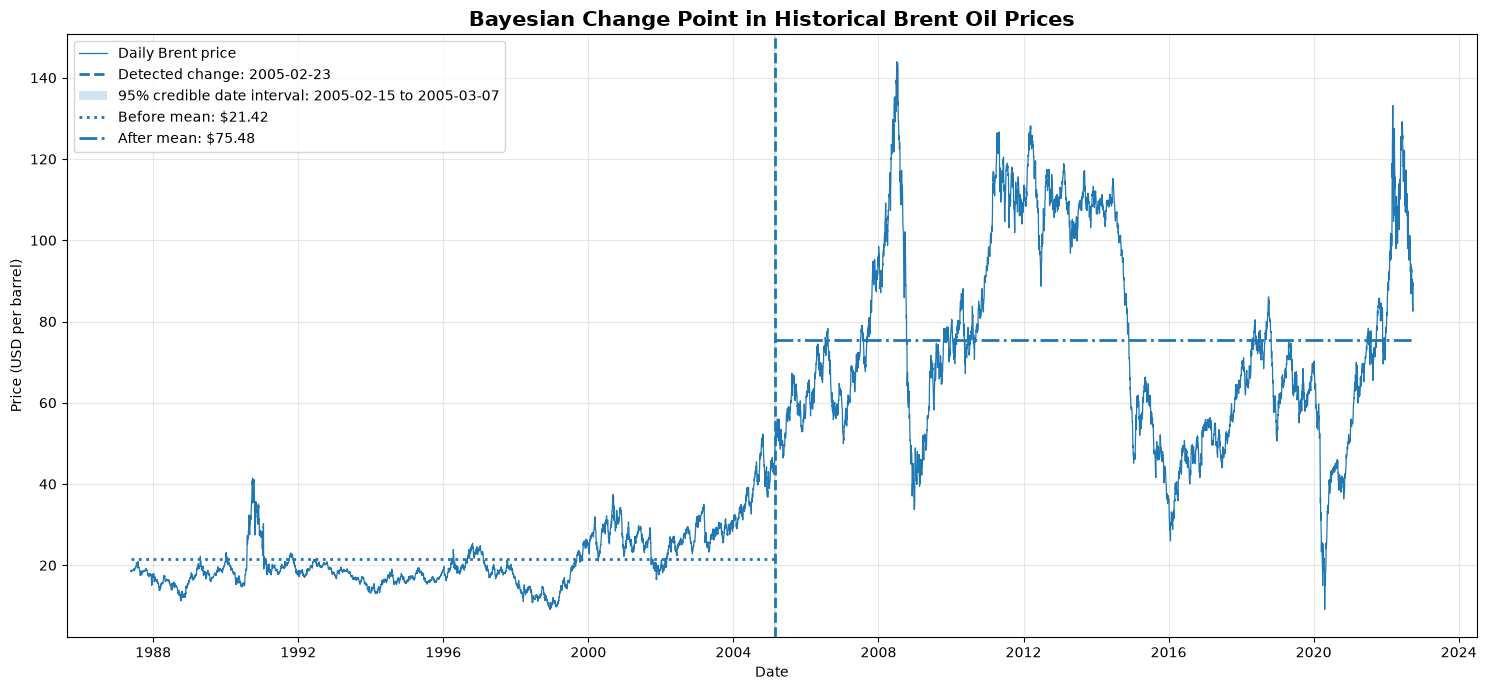

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/reports/figures/task2_detected_change_point.png


In [38]:
plt.figure(figsize=(15, 7))

plt.plot(
    model_df["Date"],
    model_df["Price"],
    linewidth=0.9,
    label="Daily Brent price"
)

plt.axvline(
    change_point_date,
    linestyle="--",
    linewidth=2,
    label=f"Detected change: {change_point_date.date()}"
)
plt.axvspan(
    credible_date_lower,
    credible_date_upper,
    alpha=0.2,
    label=(
        "95% credible date interval: "
        f"{credible_date_lower.date()} to "
        f"{credible_date_upper.date()}"
    )
)

plt.hlines(
    y=mean_before,
    xmin=model_df["Date"].min(),
    xmax=change_point_date,
    linestyles=":",
    linewidth=2,
    label=f"Before mean: ${mean_before:.2f}"
)

plt.hlines(
    y=mean_after,
    xmin=change_point_date,
    xmax=model_df["Date"].max(),
    linestyles="-.",
    linewidth=2,
    label=f"After mean: ${mean_after:.2f}"
)

plt.title(
    "Bayesian Change Point in Historical Brent Oil Prices",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

change_figure = (
    figures_directory
    / "task2_detected_change_point.png"
)

plt.savefig(
    change_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", change_figure)

In [19]:
events = pd.read_csv(events_path)

# Normalize column names.
events.columns = (
    events.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Event columns:", events.columns.tolist())

Event columns: ['date', 'event', 'category', 'expected_market_effect', 'notes']


In [ ]:
if "date" not in events.columns:
    raise ValueError(
        "The event dataset must contain a 'date' column."
    )

events["date"] = pd.to_datetime(
    events["date"],
    errors="coerce"
)

events = events.dropna(
    subset=["date"]
).copy()

events["distance_days"] = (
    events["date"] - change_point_date
).dt.days

events["absolute_distance_days"] = (
    events["distance_days"].abs()
)

nearby_events = (
    events.sort_values(
        "absolute_distance_days"
    )
    .reset_index(drop=True)
)

nearby_events.head(5)

,date,event,category,expected_market_effect,notes,distance_days,absolute_distance_days
0,2003-03-20,Iraq War begins,Geopolitical conflict,Price increase,Supply risk and Middle East instability,-706,706
1,2008-07-11,Oil price reaches record highs,Economic/market shock,Price peak,Strong demand and supply pressure before crash,1234,1234
2,2001-09-11,September 11 attacks,Geopolitical shock,High volatility,Global uncertainty and demand concerns,-1261,1261
3,2008-09-15,Lehman Brothers collapse,Global financial crisis,Price decline,Global recession and demand collapse,1300,1300
4,2011-02-15,Libyan civil war escalates,Geopolitical conflict,Price increase,Supply disruption from Libya,2183,2183


In [ ]:

signed_event_distance_days = int(
    (nearest_event_date - change_point_date).days
)

absolute_event_distance_days = abs(
    signed_event_distance_days
)

# Classify the strength of the temporal association.
if absolute_event_distance_days <= 30:
    event_association_strength = "strong"
elif absolute_event_distance_days <= 90:
    event_association_strength = "moderate"
else:
    event_association_strength = "weak"


change_point_results = {
    "model_period_start": str(
        model_df["Date"].min().date()
    ),
    "model_period_end": str(
        model_df["Date"].max().date()
    ),
    "number_of_observations": int(
        number_of_observations
    ),
    "change_point_index": int(
        tau_mode
    ),
    "change_point_date": str(
        change_point_date.date()
    ),
    "credible_date_lower": str(
        credible_date_lower.date()
    ),
    "credible_date_upper": str(
        credible_date_upper.date()
    ),
    "mean_before": round(
        float(mean_before),
        2
    ),
    "mean_after": round(
        float(mean_after),
        2
    ),
    "absolute_change": round(
        float(absolute_change),
        2
    ),
    "percentage_change": round(
        float(percentage_change),
        2
    ),
    "probability_increase": round(
        float(probability_of_increase),
        4
    ),
    "probability_decrease": round(
        float(probability_of_decrease),
        4
    ),
    "nearest_event_name": str(
        nearest_event_name
    ),
    "nearest_event_date": str(
        nearest_event_date.date()
    ),
    "event_signed_distance_days": (
        signed_event_distance_days
    ),
    "event_absolute_distance_days": (
        absolute_event_distance_days
    ),
    "event_association_strength": (
        event_association_strength
    ),
    "event_association_note": (
        "The nearest event is too distant to support a strong "
        "immediate temporal association."
        if event_association_strength == "weak"
        else
        "The event occurred relatively close to the detected "
        "change point, but temporal proximity does not prove causality."
    ),
}


results_path = (
    processed_directory
    / "change_point_results.json"
)

with open(
    results_path,
    "w",
    encoding="utf-8"
) as output_file:
    json.dump(
        change_point_results,
        output_file,
        indent=2
    )


nearby_events.to_csv(
    processed_directory
    / "event_correlations.csv",
    index=False
)


model_df.to_csv(
    processed_directory
    / "brent_prices_for_dashboard.csv",
    index=False
)


print("Saved:", results_path)

print(
    "Saved:",
    processed_directory
    / "event_correlations.csv"
)

print(
    "Saved:",
    processed_directory
    / "brent_prices_for_dashboard.csv"
)

change_point_results

Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/data/processed/change_point_results.json
Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/data/processed/event_correlations.csv
Saved: /Users/mac/brent-oil-change-point-analysis/brent-oil-change-point-analysis/data/processed/brent_prices_for_dashboard.csv


{'model_period_start': '1987-05-20',
 'model_period_end': '2022-09-30',
 'number_of_observations': 8980,
 'change_point_index': 4520,
 'change_point_date': '2005-02-23',
 'credible_date_lower': '2005-02-15',
 'credible_date_upper': '2005-03-07',
 'mean_before': 21.42,
 'mean_after': 75.48,
 'absolute_change': 54.06,
 'percentage_change': 252.35,
 'probability_increase': 1.0,
 'probability_decrease': 0.0,
 'nearest_event_name': 'Iraq War begins',
 'nearest_event_date': '2003-03-20',
 'event_signed_distance_days': -706,
 'event_absolute_distance_days': 706,
 'event_association_strength': 'weak',
 'event_association_note': 'The nearest event is too distant to support a strong immediate temporal association.'}

In [37]:
nearest_event_name = str(
    nearest_event[event_name_column]
)

nearest_event_date = nearest_event["date"]

signed_event_distance_days = int(
    (nearest_event_date - change_point_date).days
)

absolute_event_distance_days = abs(
    signed_event_distance_days
)

if signed_event_distance_days < 0:
    event_timing_description = (
        f"{absolute_event_distance_days} days before "
        "the detected change point"
    )
elif signed_event_distance_days > 0:
    event_timing_description = (
        f"{absolute_event_distance_days} days after "
        "the detected change point"
    )
else:
    event_timing_description = (
        "on the same date as the detected change point"
    )

if absolute_event_distance_days <= 30:
    event_association_strength = "strong"
elif absolute_event_distance_days <= 90:
    event_association_strength = "moderate"
else:
    event_association_strength = "weak"

print("Nearest researched event:", nearest_event_name)
print("Event date:", nearest_event_date.date())
print("Detected change date:", change_point_date.date())
print("Event timing:", event_timing_description)
print("Temporal association strength:", event_association_strength)

Nearest researched event: Iraq War begins
Event date: 2003-03-20
Detected change date: 2005-02-23
Event timing: 706 days before the detected change point
Temporal association strength: weak


In [32]:
print("Model start:", model_df["Date"].min().date())
print("Model end:", model_df["Date"].max().date())
print("Model observations:", len(model_df))

Model start: 1987-05-20
Model end: 2022-09-30
Model observations: 8980


In [34]:
raw_check = pd.read_csv(raw_data_path)

raw_check["Original_Date"] = (
    raw_check["Date"]
    .astype(str)
    .str.strip()
)

# Parse the first date format: 20-May-87
parsed_dates = pd.to_datetime(
    raw_check["Original_Date"],
    format="%d-%b-%y",
    errors="coerce"
)

# Parse the second date format: Apr 22, 2020
second_format_mask = parsed_dates.isna()

parsed_dates.loc[second_format_mask] = pd.to_datetime(
    raw_check.loc[
        second_format_mask,
        "Original_Date"
    ],
    format="%b %d, %Y",
    errors="coerce"
)

raw_check["Parsed_Date"] = parsed_dates

print("Raw rows:", len(raw_check))
print("First raw date:", raw_check["Date"].iloc[0])
print("Last raw date:", raw_check["Date"].iloc[-1])

print(
    "Parsed date range:",
    raw_check["Parsed_Date"].min(),
    "to",
    raw_check["Parsed_Date"].max()
)

print(
    "Dates that failed parsing:",
    raw_check["Parsed_Date"].isna().sum()
)

display(
    raw_check.loc[
        raw_check["Parsed_Date"].isna(),
        ["Date", "Price"]
    ].head(20)
)

Raw rows: 9011
First raw date: 20-May-87
Last raw date: Nov 14, 2022
Parsed date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
Dates that failed parsing: 0


,Date,Price


In [35]:
print("Missing dates:", model_df["Date"].isna().sum())
print("Missing prices:", model_df["Price"].isna().sum())
print("Duplicate dates:", model_df["Date"].duplicated().sum())
print("Non-positive prices:", (model_df["Price"] <= 0).sum())

assert model_df["Date"].min() == pd.Timestamp("1987-05-20")
assert model_df["Date"].max() == pd.Timestamp("2022-09-30")
assert model_df["Date"].isna().sum() == 0
assert model_df["Price"].isna().sum() == 0
assert model_df["Date"].duplicated().sum() == 0
assert (model_df["Price"] <= 0).sum() == 0

print("\n✅ The model input dataset is valid.")

Missing dates: 0
Missing prices: 0
Duplicate dates: 0
Non-positive prices: 0

✅ The model input dataset is valid.


In [33]:
from arviz_stats import summary

parameter_names = [
    "tau",
    "mu_before",
    "mu_after",
    "sigma"
]

model_summary = summary(
    trace,
    var_names=parameter_names,
    kind="all",
    ci_prob=0.95,
    ci_kind="eti",
    round_to=3
)

display(model_summary)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.869,3.279,4514.000,4528.000,1329.136,1153.020,1.003,0.090,0.067
mu_before,21.423,0.273,20.875,21.971,7350.404,4908.782,1.001,0.003,0.002
mu_after,75.485,0.277,74.931,76.015,4600.898,4316.549,1.000,0.004,0.003
sigma,18.595,0.140,18.331,18.884,5813.919,4304.103,1.000,0.002,0.001
